# Heart Disease prediction - Logistic Regression

The model is a binary classification model that predicts whether a patient has heart disease based on the medical-related inout feature

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

In [2]:
train = pd.read_csv("../1-Data/train_processed.csv")
x_train = train.drop(columns=["HeartDisease"])
y_train = train["HeartDisease"]
print("Train shape: ", train.shape)

Train shape:  (733, 16)


In [3]:
test = pd.read_csv("../1-Data/test_processed.csv")
x_test = test.drop(columns=["HeartDisease"])
y_test = test["HeartDisease"]
print("Test shape: ", test.shape)

Test shape:  (184, 16)


# 1. Baseline model (C=1.0, threshold=0.5)

Use default regularization strength and threshold

Classification Report:
               precision    recall  f1-score   support

       Normal       0.88      0.85      0.86        82
Heart Disease       0.88      0.90      0.89       102

     accuracy                           0.88       184
    macro avg       0.88      0.88      0.88       184
 weighted avg       0.88      0.88      0.88       184

Accuracy: 0.8804347826086957
Precision: 0.8803302675585284
Recall: 0.8804347826086957
F1-Score: 0.8802771393878751


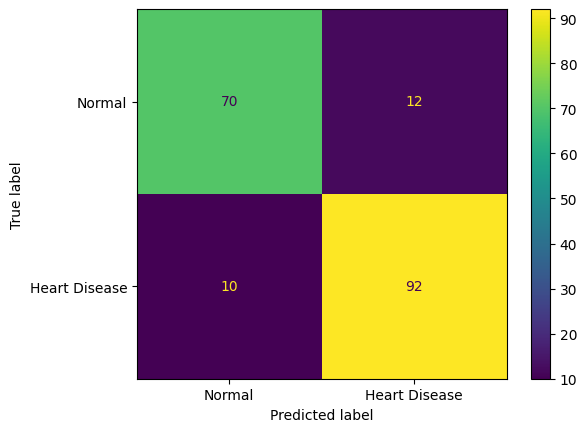

In [4]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
cr = classification_report(y_test, y_pred, target_names=["Normal", "Heart Disease"])
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)

print("Classification Report:")
print(cr)
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1-Score: {f1}")

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Heart Disease"])
display.plot()
plt.show()


# 2. Improved model (C=0.01, threshold=0.45)

These values were chosen because it improves model smoothing via regularization, increases sensitivity to heart disease, and still maintain a balanced overall performance metrics

Classification Report:
               precision    recall  f1-score   support

       Normal       0.91      0.83      0.87        82
Heart Disease       0.87      0.93      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.88      0.88       184
 weighted avg       0.89      0.89      0.89       184

Accuracy: 0.8858695652173914
Precision: 0.8715596330275229
Recall: 0.9313725490196079
F1-Score: 0.9004739336492891


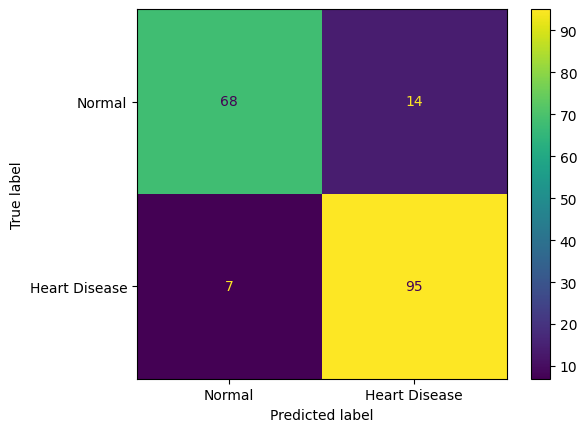

In [5]:
C = 0.01 # Regularization strength
threshold = 0.45 # Adjust the threshold for classifying as heart disease

model = LogisticRegression(C=C, random_state=42, max_iter=1000)
model.fit(x_train, y_train)
y_pred = (model.predict_proba(x_test)[:, 1] >= threshold).astype(int)
cr = classification_report(y_test, y_pred, target_names=["Normal", "Heart Disease"])
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Classification Report:")
print(cr)
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1-Score: {f1}")

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Heart Disease"])
display.plot()
plt.show()


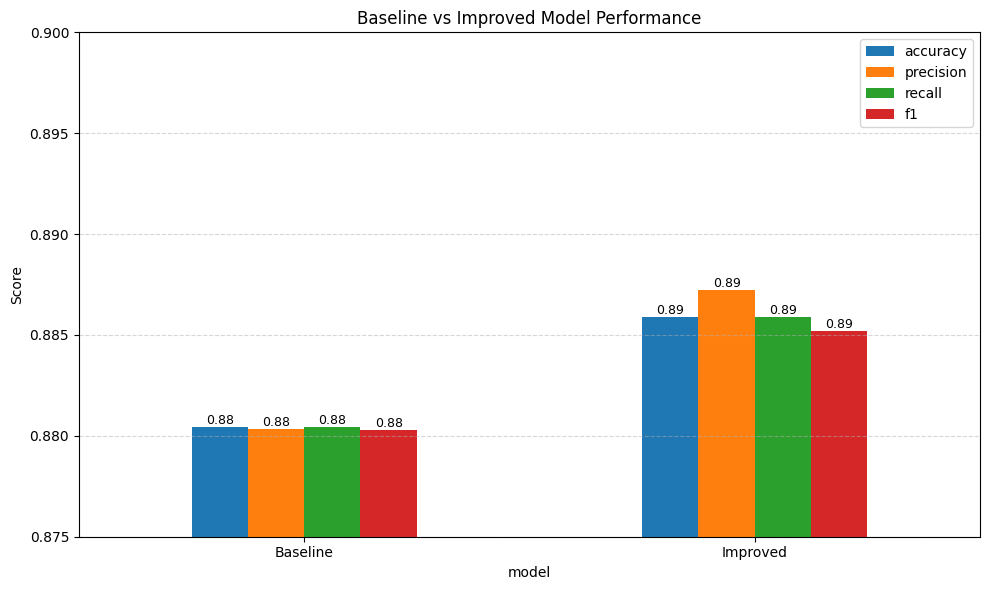

In [8]:
comparison_results = []
for label, C, threshold in [
    ("Baseline", 1.0, 0.5),
    ("Improved", 0.01, 0.45),
]:
    temp_model = LogisticRegression(C=C, random_state=42, max_iter=1000)
    temp_model.fit(x_train, y_train)
    y_pred_temp = (temp_model.predict_proba(x_test)[:, 1] >= threshold).astype(int)
    comparison_results.append({
        "model": label,
        "accuracy": accuracy_score(y_test, y_pred_temp),
        "precision": precision_score(y_test, y_pred_temp, average="weighted"),
        "recall": recall_score(y_test, y_pred_temp, average="weighted"),
        "f1": f1_score(y_test, y_pred_temp, average="weighted"),
    })

comparison_df = pd.DataFrame(comparison_results).set_index("model")

ax = comparison_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Baseline vs Improved Model Performance")
ax.set_ylabel("Score")
ax.set_ylim(0.875, 0.9)
ax.grid(axis="y", linestyle="--", alpha=0.5)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()